In [1]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
import itertools
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.8',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.4',
                'lemon_creek':'58.5_-134.4',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too hPPigh --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

In [2]:
params = {
    'kp': [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5],
    'lapse_rate':[-3.5, -4, -4.5, -5, -5.5, -6, -6.5, -7, -7.5, -8, -8.5, -9],
}

site_dict = {'gulkana':['T','Z'],
             'kahiltna':['KPS', 'KQU'],
             'wolverine':['EC']}

keys = list(params.keys())
values = list(params.values())

fn = 'paper2/recalibrate_{s}/grid_{g}_{s}_{p}_FINAL_0.nc'

all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
snow_only = True
for glacier in site_dict:
    if glacier not in best_dict: best_dict[glacier] = {}
    
    for site in site_dict[glacier]:
        best = np.inf 

        for param_values in itertools.product(*values):
            params_str = '_'.join([p.replace('_','') + str(v) for p, v in zip(keys, param_values)])
            fn_ds = base_fp + fn.format(g=glacier, s=site, p=params_str)
            try:
                ds = xr.open_dataset(fn_ds)
                assert ds.melt.sum() != 0
            except:
                continue

            albedo_data = Albedo(glacier, site, use='all')
            albedo_data.get_model_albedo(ds, snow_only=snow_only)
            mb_data = MassBalance(glacier, site, use='benchmark', min_n_winter=0)
            mb_data.get_model_mb(ds)

            if mb_data.dataset == 'seasonal':
                error , _= mb_data.mae(True)
            else:
                error = mb_data.mae()

            if error < best:
                best = error 
                best_ds = ds.load()
                best_params = param_values

        albedo_data = Albedo(glacier, site, use='all')
        albedo_data.get_model_albedo(best_ds, snow_only=snow_only)
        mb_data = MassBalance(glacier, site, use='benchmark', min_n_winter=0)
        mb_data.get_model_mb(best_ds)

        best_str = ' '.join([p+' '+str(v) for p, v in zip(keys, best_params)])
        print(glacier, site, best_str)
        best_dict[glacier][site] = {'lapse_rate': best_params[0]}
        
        if mb_data.dataset == 'seasonal':
            mae_summer, mae_winter = mb_data.mae(True)
            print('Summer mass balance MAE:',mae_summer)
            print('Winter mass balance MAE:',mae_winter)

            me_summer, me_winter = mb_data.bias(True)
            print('Summer mass balance bias:',me_summer)
            print('Winter mass balance bias:',me_winter)
        else:
            print('Annual mass balance MAE:',mb_data.mae())
            print('Annual mass balance bias', mb_data.bias())

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

        # plot
        fig, ax = mb_data.plot_mb()
        ax.set_title(f'{glacier} {site} with {best_str}')
        plt.savefig(base_fp + f'../figs/{glacier+site}_best_mb.png')
        plt.show()
        plt.close()
        
        # albedo_data.plot_timeseries()
        albedo_data.plot_1to1()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)


KeyboardInterrupt: 

In [3]:
for glacier in best_dict:
    for site in best_dict[glacier]:
        best_dict[glacier][site] = {'wind_factor':best_dict[glacier][site][0],
                                    'lapse_rate': best_dict[glacier][site][1]}
        
best_dict

{'gulkana': {'T': {'wind_factor': 3.5, 'lapse_rate': -6.5},
  'Z': {'wind_factor': 3.5, 'lapse_rate': -6.5}},
 'kahiltna': {'KPS': {'wind_factor': 3, 'lapse_rate': -6.5},
  'KQU': {'wind_factor': 2.5, 'lapse_rate': -6.5}},
 'wolverine': {'EC': {'wind_factor': 2, 'lapse_rate': -6.5}}}

In [5]:
import pickle
pickle_name = 'best_firn_params.pkl'
if False: # os.path.exists(pickle_name):
    with open(pickle_name, 'rb') as f:
        best_dict = pickle.load(f)
else:
    with open(pickle_name, 'wb') as f:
        pickle.dump(best_dict, f)
best_dict

{'gulkana': {'T': {'lapse_rate': -3.5}, 'Z': {'lapse_rate': -3.5}},
 'kahiltna': {'KPS': {'lapse_rate': -3.5}, 'KQU': {'lapse_rate': -7}},
 'wolverine': {'EC': {'lapse_rate': -9}}}

In [18]:
def optimize_regional_lapse_rate(site_dict, params, base_fp):
    """
    Optimizes a single global lapse rate across all sites while optimizing 
    individual precipitation factors (kp) for each site using normalized MAE.
    """
    keys = list(params.keys())

    fn = 'paper2/recalibrate_{s}/grid_{g}_{s}_{p}_FINAL_0.nc'
    
    # --- STEP 1: Pre-calculate and cache errors for all valid combinations ---
    error_cache = {}
    
    for glacier, sites in site_dict.items():
        error_cache[glacier] = {}
        for site in sites:
            error_cache[glacier][site] = {'winter': {}, 'summer': {}}
            
            for kp in params['kp']:
                for lr in params['lapse_rate']:
                    p_vals = [kp, lr]
                    params_str = '_'.join([p.replace('_','') + str(v) for p, v in zip(keys, p_vals)])
                    
                    fn_ds = base_fp + fn.format(g=glacier, s=site, p=params_str)
                    
                    try:
                        with xr.open_dataset(fn_ds) as ds:
                            if ds.melt.sum() == 0:
                                print(f'did not store properly for {fn_ds}')
                                continue
                            
                            # Calculate mass balance error
                            mb_data = MassBalance(glacier, site, use='benchmark', min_n_winter=0)
                            mb_data.get_model_mb(ds)
                            
                            err_summer, err_winter = mb_data.mae(True)
                                
                            error_cache[glacier][site]['winter'][(kp, lr)] = err_winter
                            error_cache[glacier][site]['summer'][(kp, lr)] = err_summer
                    except Exception as e:
                        print(f'! oops, error {e}')
                        # Skip missing files or errors silently
                        continue

    # --- STEP 2: Find normalization factors per site ---
    # We normalize by the minimum error found at each site so different magnitudes don't skew the global LR.
    norm_errors = {}
    for glacier in site_dict:
        norm_errors[glacier] = {}
        for site in site_dict[glacier]:
            norm_errors[glacier][site] = {}
            for err_type in ['winter','summer']:
                errors = np.array(list(error_cache[glacier][site][err_type].values()))
                min_error = np.min(errors)
                max_error = np.max(errors)
                norm_errors[glacier][site][err_type] = {}
                for ps in error_cache[glacier][site][err_type]:
                    norm_errors[glacier][site][err_type][ps] = (error_cache[glacier][site][err_type][ps] - min_error) / (max_error - min_error)

    # --- STEP 3: Grid search for the best global lapse rate ---
    best_global_error = np.inf
    best_global_lr = None
    best_kp_per_site = {}

    min_norm_error = 0.2

    all_site_options = {}
    for site in site_dict[glacier]:
        all_site_options[site] = []

    for lr in params['lapse_rate']:
        current_lr_total_norm_error = 0
        current_kp_selection = {}
        valid_lr_setup = True
        temp_loop_options = {}
        
        for glacier, sites in site_dict.items():
            current_kp_selection[glacier] = {}

            for site in sites:
                # Find the best kp for *this specific* lapse rate at *this specific* site
                best_site_kp = None
                best_site_norm_error = np.inf

                temp_loop_options[site] = []
                
                for kp in params['kp']:
                    if (kp, lr) in norm_errors[glacier][site]['winter']:
                        norm_error = (norm_errors[glacier][site]['winter'][(kp, lr)] + norm_errors[glacier][site]['summer'][(kp, lr)]) / 2
                        
                        if norm_error < best_site_norm_error:
                            best_site_norm_error = norm_error
                            best_site_kp = kp

                        if norm_error < min_norm_error:
                            temp_loop_options[site].append((kp, lr))
                
                # If a site is missing data completely for this lapse rate, it's an invalid global candidate
                if best_site_kp is None:
                    valid_lr_setup = False
                    break
                
                current_kp_selection[glacier][site] = {
                    'kp': best_site_kp,
                    'norm_error': best_site_norm_error,
                }

            if not valid_lr_setup:
                break
        
        if not valid_lr_setup:
            continue

        for site in site_dict[glacier]:
            all_site_options[site].extend(temp_loop_options[site])
            
        # Sum up normalized errors across all sites for this lapse rate
        total_norm_error = sum(
            current_kp_selection[g][s]['norm_error'] 
            for g in site_dict for s in site_dict[g]
        )
        
        if total_norm_error < best_global_error:
            best_global_error = total_norm_error
            best_global_lr = lr
            
            # Deep copy manually since it's two levels deep
            best_kp_per_site = {
                glacier: sites_dict.copy() 
                for glacier, sites_dict in current_kp_selection.items()
            }
    print(all_site_options)
            
    # --- STEP 4: Format Results ---
    results = {
        'best_global_lapse_rate': best_global_lr,
        'total_normalized_error': best_global_error,
    }
    
    for glacier, sites in site_dict.items():
        results[glacier] = {}
        for site in sites:
            results[glacier][site] = {
                'kp': best_kp_per_site[glacier][site]['kp']
            }
            mb = MassBalance(glacier, site, min_n_winter=0)
            p_vals = (best_kp_per_site[glacier][site]['kp'], best_global_lr)
            params_str = '_'.join([p.replace('_','') + str(v) for p, v in zip(keys, p_vals)])
            fn_ds = base_fp + fn.format(g=glacier, s=site, p=params_str)
            ds = xr.open_dataset(fn_ds)
            mb.get_model_mb(ds)
            fig, ax = mb.plot_mb()
            ax.set_title(f'{glacier} {site} best seasonal mass balance\nkp = {p_vals[0]}  lapse rate = {best_global_lr} K/km')
            plt.show()
            
    return results, all_site_options

{'T': [(2.25, -3.5), (2.75, -3.5), (3, -3.5), (3.25, -3.5), (3.5, -3.5), (2.75, -4), (3, -4), (3.25, -4)], 'Z': [(2.25, -3.5), (3, -3.5), (3.25, -3.5), (3.5, -3.5), (2.25, -4), (3.25, -4), (3.5, -4), (2.25, -4.5), (3.25, -4.5)]}


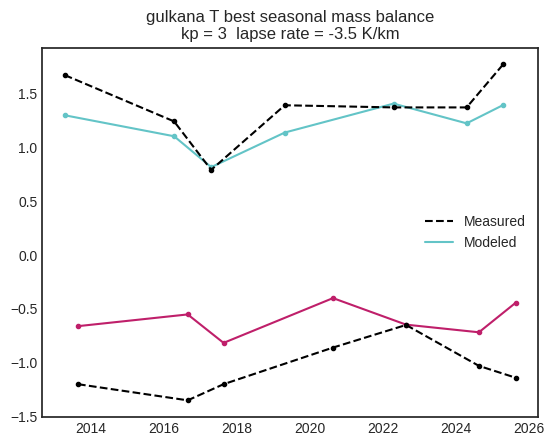

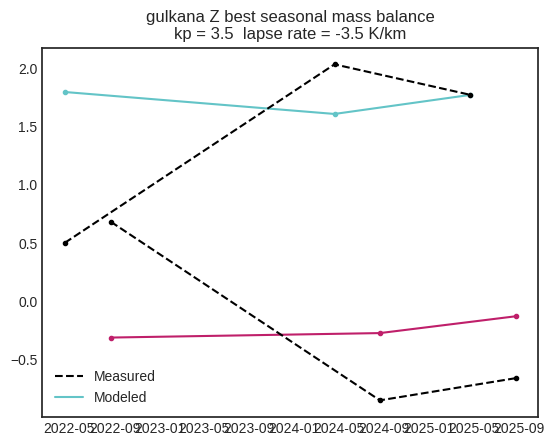

did not store properly for /trace/group/rounce/cvwilson/Output/paper2/recalibrate_EC/grid_wolverine_EC_kp2.5_lapserate-4.5_FINAL_0.nc
{'EC': [(2.25, -5), (2.5, -5), (2, -5.5), (2.25, -5.5), (2.5, -5.5), (1.75, -6), (2, -6), (2.25, -6), (2.5, -6), (1.5, -6.5), (1.75, -6.5), (2, -6.5), (2.25, -6.5), (2.5, -6.5), (2.75, -6.5), (1.5, -7), (1.75, -7), (2, -7), (2.25, -7), (2.5, -7), (2.75, -7), (1.25, -7.5), (1.5, -7.5), (1.75, -7.5), (2, -7.5), (2.25, -7.5), (2.5, -7.5), (1.25, -8), (1.5, -8), (1.75, -8), (2, -8), (2.25, -8), (2.5, -8), (1.25, -8.5), (1.5, -8.5), (1.75, -8.5), (2, -8.5), (2.25, -8.5), (2.5, -8.5), (1, -9), (1.25, -9), (1.5, -9), (1.75, -9), (2, -9), (2.25, -9), (2.5, -9)]}


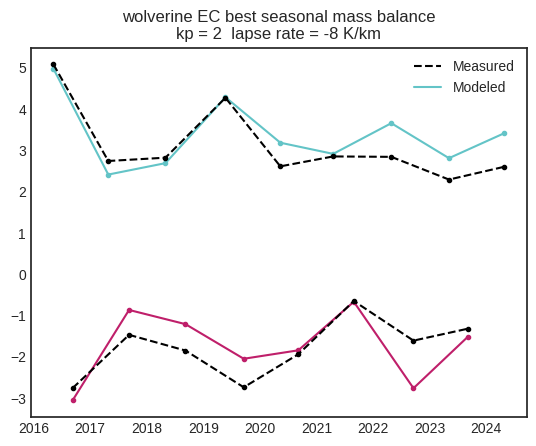

{'KPS': [(1.5, -3.5), (1.75, -3.5), (2, -3.5), (2.25, -3.5), (2.5, -3.5), (1.5, -4), (1.75, -4), (2, -4), (2.25, -4), (2.5, -4), (1.5, -4.5), (1.75, -4.5), (2, -4.5), (2.25, -4.5), (1.5, -5), (1.75, -5), (2, -5), (2.25, -5), (1.5, -5.5), (1.75, -5.5), (2, -5.5), (2.25, -5.5), (1.75, -6), (2, -6), (2.25, -6), (1.75, -6.5), (2, -6.5), (2.25, -6.5), (1.75, -7), (2, -7), (2.25, -7), (1.75, -7.5), (2, -7.5), (2.25, -7.5), (1.75, -8), (2, -8), (2.25, -8), (1.75, -8.5), (2, -8.5), (2.25, -8.5), (1.75, -9), (2, -9), (2.25, -9)], 'KQU': [(0.5, -3.5), (0.75, -3.5), (1, -3.5), (1.25, -3.5), (2.25, -3.5), (0.5, -4), (0.75, -4), (1, -4), (1.25, -4), (2.25, -4), (0.5, -4.5), (0.75, -4.5), (1, -4.5), (2.25, -4.5), (0.5, -5), (0.75, -5), (1, -5), (2.25, -5), (0.5, -5.5), (0.75, -5.5), (1, -5.5), (2.25, -5.5), (0.5, -6), (0.75, -6), (1, -6), (2.25, -6), (0.5, -6.5), (0.75, -6.5), (1, -6.5), (2.25, -6.5), (0.5, -7), (0.75, -7), (1, -7), (2.25, -7), (0.5, -7.5), (0.75, -7.5), (1, -7.5), (2.25, -7.5), (0.

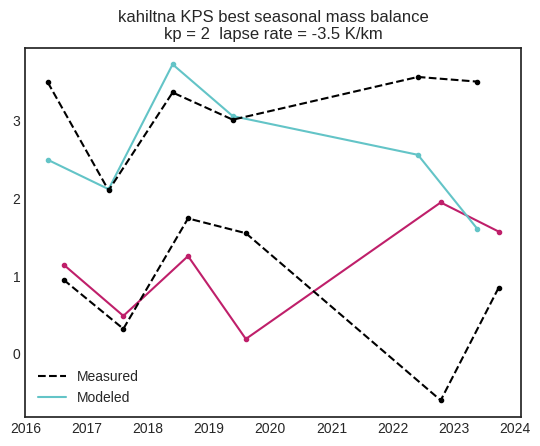

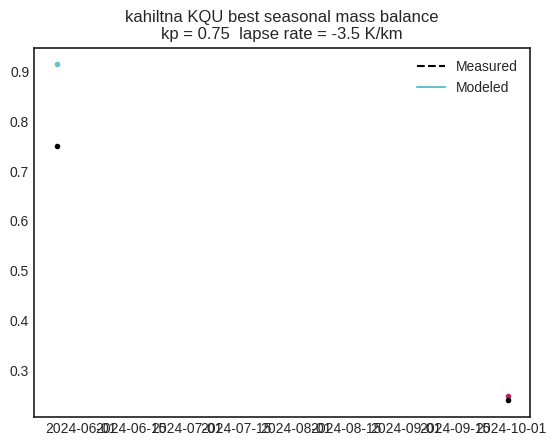

In [19]:
params = {
    'kp': [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5],
    'lapse_rate':[-3.5, -4, -4.5, -5, -5.5, -6, -6.5, -7, -7.5, -8, -8.5, -9],
}

results_gulkana, gulk_options = optimize_regional_lapse_rate({'gulkana': ['T','Z']}, params, base_fp)
results_wolverine, wolv_options = optimize_regional_lapse_rate({'wolverine': ['EC']}, params, base_fp)
results_kahiltna, kah_options = optimize_regional_lapse_rate({'kahiltna': ['KPS','KQU']}, params, base_fp)

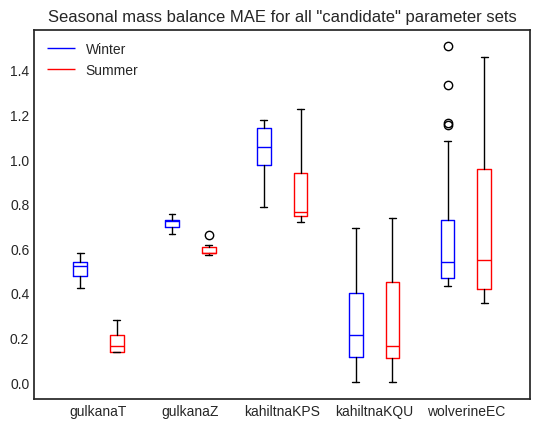

In [42]:
error = []
by_glacier = {'gulkana': {'T': gulk_options['T'], 'Z': gulk_options['Z']},
              'kahiltna': {'KPS': kah_options['KPS'], 'KQU': kah_options['KQU']},
              'wolverine': {'EC': wolv_options['EC']}}
fn = 'paper2/recalibrate_{s}/grid_{g}_{s}_{p}_FINAL_0.nc'
i = 0
for glacier in by_glacier:
    for site in by_glacier[glacier]:
        summers = []
        winters =  []
        for p_vals in by_glacier[glacier][site]:
            params_str = '_'.join([p.replace('_','') + str(v) for p, v in zip(['kp','lapse_rate'], p_vals)])
            fn_ds = base_fp + fn.format(g=glacier, s=site, p=params_str)
            ds = xr.open_dataset(fn_ds)
            mb = MassBalance(glacier, site, min_n_winter = 0)
            mb.get_model_mb(ds)
            summer, winter = mb.mae(True)
            summers.append(summer)
            winters.append(winter)
        
        plt.boxplot(summers, positions = [i-0.2], boxprops=dict(color='blue'),medianprops=dict(color='blue'))
        plt.boxplot(winters, positions= [i+0.2], boxprops=dict(color='red'),medianprops=dict(color='red'), )
        i += 1

plt.boxplot([np.nan], boxprops=dict(color='blue'), medianprops=dict(color='blue'), label='Winter')
plt.boxplot([np.nan], boxprops=dict(color='red'), medianprops=dict(color='red'), label='Summer')
plt.legend()

plt.xticks([0,1,2,3,4], labels=['gulkanaT','gulkanaZ','kahiltnaKPS','kahiltnaKQU','wolverineEC'])
plt.title('Seasonal mass balance MAE for all "candidate" parameter sets')
plt.show()

In [45]:
import pickle
with open('firn_param_options.pkl', 'wb') as f:
    pickle.dump(by_glacier, f)

In [40]:
best_dict = {'gulkana': {'T': {'kp': results_gulkana['gulkana']['T']['kp'],
                               'lapse_rate': results_gulkana['best_global_lapse_rate']},
                         'Z': {'kp': results_gulkana['gulkana']['Z']['kp'],
                               'lapse_rate': results_gulkana['best_global_lapse_rate']}},

            'wolverine': {'EC': {'kp': results_wolverine['wolverine']['EC']['kp'],
                               'lapse_rate': results_wolverine['best_global_lapse_rate']}},

            'kahiltna': {'KPS': {'kp': results_kahiltna['kahiltna']['KPS']['kp'],
                                 'lapse_rate': results_kahiltna['best_global_lapse_rate']},
                        'KQU': {'kp': results_kahiltna['kahiltna']['KQU']['kp'],
                                 'lapse_rate': results_kahiltna['best_global_lapse_rate']}}}
best_dict


{'gulkana': {'T': {'kp': 3, 'lapse_rate': -3.5},
  'Z': {'kp': 3.5, 'lapse_rate': -3.5}},
 'wolverine': {'EC': {'kp': 2, 'lapse_rate': -8}},
 'kahiltna': {'KPS': {'kp': 2, 'lapse_rate': -3.5},
  'KQU': {'kp': 0.75, 'lapse_rate': -3.5}}}

In [41]:
import pickle
pickle_name = 'best_firn_params.pkl'
if False: # os.path.exists(pickle_name):
    with open(pickle_name, 'rb') as f:
        best_dict = pickle.load(f)
else:
    with open(pickle_name, 'wb') as f:
        pickle.dump(best_dict, f)
best_dict

{'gulkana': {'T': {'kp': 3, 'lapse_rate': -3.5},
  'Z': {'kp': 3.5, 'lapse_rate': -3.5}},
 'wolverine': {'EC': {'kp': 2, 'lapse_rate': -8}},
 'kahiltna': {'KPS': {'kp': 2, 'lapse_rate': -3.5},
  'KQU': {'kp': 0.75, 'lapse_rate': -3.5}}}

In [ ]:
# # TROUBLESHOOTING FIGURE: ALBEDO TIMESERIES IN EACH YEAR FOR EACH GLACIER 
# plot = False
# snow_only = False 
# deltas = True 
# fn = 'ddf/grid_{g}_{s}_windfactor{w}_0.nc'

# glaciers = ['gulkana','kennicott', 'wolverine', 'lemon_creek', 'kahiltna']
# sites = [['B','D'], ['GTL','GTH'], ['N','EC'], ['B','D'], ['K53','K17b']]
# all_meas_albedo = [] 
# all_mod_albedo = []
# all_time_albedo = []

# for (g, (site1, site2)) in zip(glaciers, sites):
#     # load datasets
#     ds1 = xr.open_dataset(base_fp + fn.format(g=g, s=site1, w=best_dict[g][site1]))
#     ds2 = xr.open_dataset(base_fp + fn.format(g=g, s=site2, w=best_dict[g][site2]))

#     # get observations
#     a1 = Albedo(g, site1)
#     a2 = Albedo(g, site2)

#     # process model
#     a1.get_model_albedo(ds1, snow_only=snow_only)
#     a2.get_model_albedo(ds2, snow_only=snow_only)
#     if deltas:
#         a1.get_deltas()
#         a2.get_deltas()
#     for a in [a1, a2]:
#         for meas, mod, t in zip(a.meas, a.mod, a.time):
#             all_meas_albedo.append(meas)
#             all_mod_albedo.append(mod)
#             all_time_albedo.append(t)

#     if plot:
#         years = np.arange(2019, 2025)
#         fig, axes = plt.subplots(2, 3, figsize=(8, 6), gridspec_kw={'hspace':0.3, 'wspace': 0.3})
#         axes = axes.flatten()
#         for yr, ax in zip(years, axes):
#             dates = pd.date_range(f'{yr}-04-01',f'{yr}-08-20')

#             for i, a in enumerate([a1, a2]):
#                 time, mod, meas = a.get_dates(dates)
#                 if i == 0: ax.scatter(time, meas, label='Satellite')
#                 else: ax.scatter(time, meas)
#                 ax.plot(time, mod, label=site)

#             # if g == 'gulkana':
#             #     if yr == 2024:
#             #         df = pd.read_csv('../../climate_data/AWS/Processed/gulkana2024_walbedo.csv', parse_dates=True, index_col=0)
#             #         df = df.loc[pd.date_range(f'{yr}-04-20',f'{yr}-08-20')]
#             #         ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             #     elif yr == 2025:
#             #         df = pd.read_csv('../../climate_data/AWS/Processed/gulkanaB2025_albedo.csv', parse_dates=True, index_col=0)
#             #         df = df.loc[df.index.hour.isin(range(13, 15))].resample('d').mean()
#             #         df = df.loc[pd.date_range(f'{yr}-04-23',f'{yr}-08-20')]
#             #         ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             # ax.set_xlim(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'))
#             ax.set_xticks(pd.date_range(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'), freq='2MS'))
#             ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%Y'))
#             ax.minorticks_on()
#             ax.tick_params(length=5)
#         ax.legend()
#         name = ' '.join(g.split('_')).capitalize()
#         fig.suptitle(name, y=0.93)
#         plt.savefig(base_fp + f'../figs/ddf/albedo_comparison_{g}.png', bbox_inches='tight')
#         plt.show()

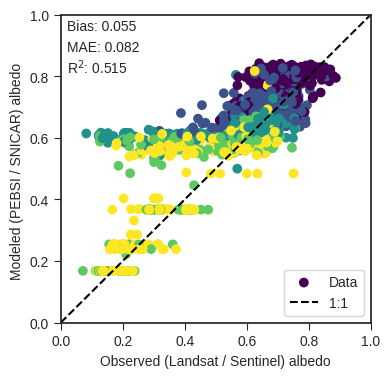

In [16]:
fn = 'ddf/{g}{s}_2026_05_08_base_0.nc'
all_meas_albedo = [] 
all_mod_albedo = []
all_time_albedo = []
deltas = False
snow_only = False

for glacier in site_dict:
    for site in site_dict[glacier]:    
        ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
        assert ds.melt.sum() > 0, 'did not save'
        albedo = Albedo(glacier, site)
        albedo.get_model_albedo(ds, snow_only=snow_only)
        if deltas:
            albedo.get_deltas()

        for meas, mod, t in zip(albedo.meas, albedo.mod, albedo.time):
            all_meas_albedo.append(meas)
            all_mod_albedo.append(mod)
            all_time_albedo.append(t)

fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
if deltas:
    minval, maxval = -0.7, 0.02
else:
    minval, maxval = 0, 1
ax.plot([minval, maxval],[minval, maxval],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(minval, maxval)
ax.set_ylim(minval, maxval)
ax.tick_params(length=5)
if not deltas:
    ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
    ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
else:
    ax.set_ylabel('$\Delta$ Modeled (PEBSI / SNICAR) albedo')
    ax.set_xlabel('$\Delta$ Observed (Landsat / Sentinel) albedo')
deltastr = '_deltas' if deltas else ''
plt.savefig(f'/trace/group/rounce/cvwilson/figs/ddf/albedo{deltastr}.png', bbox_inches='tight', dpi=300)
plt.show()

taku TKG3 ['2020-09-29T00:00:00.000000000' '2020-09-30T00:00:00.000000000'
 '2020-10-01T00:00:00.000000000' '2020-10-02T00:00:00.000000000'
 '2020-10-03T00:00:00.000000000']
kahiltna K53 ['2015-05-09T00:00:00.000000000' '2015-05-10T00:00:00.000000000'
 '2015-05-11T00:00:00.000000000' '2015-05-12T00:00:00.000000000'
 '2015-05-13T00:00:00.000000000']
lemon_creek B ['2020-09-25T00:00:00.000000000' '2020-09-26T00:00:00.000000000'
 '2020-09-27T00:00:00.000000000' '2020-09-28T00:00:00.000000000']
lemon_creek C ['2020-10-04T00:00:00.000000000' '2020-10-05T00:00:00.000000000'
 '2020-10-06T00:00:00.000000000' '2020-10-07T00:00:00.000000000'
 '2020-10-08T00:00:00.000000000']


/tmp/ipykernel_517294/1571522312.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


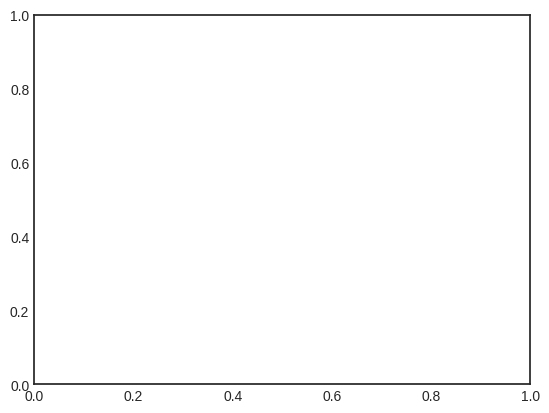

In [66]:
glacier, site = 'wolverine','B'
for glacier in ['taku','kahiltna', 'lemon_creek']:
    for site in site_dict[glacier]:
        ds = xr.open_dataset(base_fp + 'ddf/{g}{s}_2026_05_08_base_0.nc'.format(g=glacier, s=site))
        snow_depth = ds['layerheight'].where(ds['layertype'] < 1).sum(dim='layer').resample(time='1d').min()

        dsa = ds.albedo.sel(time=pd.date_range(ds.time.values[0], ds.time.values[-1]))
        dsa = dsa.where(snow_depth > 0.05)
        # plt.hist(ds.values, label=glacier+site)
        time_weird = dsa.where(dsa < 0.45, drop=True).time.values[:5]
        if len(time_weird) > 0:
            k = ds.sel(time=time_weird)
            print(glacier, site, time_weird)
            # print(k.snowdepth.values, k.firndepth.values, k.albedo.values)
plt.legend()

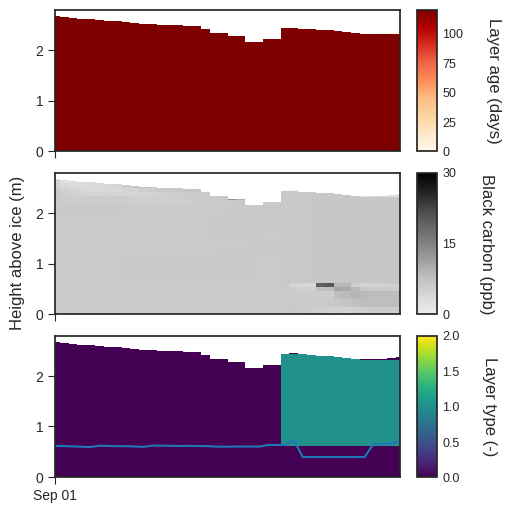

In [64]:
visualize_layers(ds, pd.date_range('2020-09-01', '2020-10-10'), ['layerage','layerBC','layertype'])
ga = ds.sel(time=pd.date_range('2020-09-01', '2020-10-10'))
plt.plot(ga.time, ga.albedo)

In [ ]:

# albedo.plot_1to1()
# for year in range(2019, 2025):
#     albedo.plot_timeseries(years=[year])

In [43]:
glacier, site = 'taku','Taku-1'
ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
ds = ds.sel(time=slice('2016-07-18','2016-07-19'), layer=0).max(dim='time')
print('TAKU')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')

l = LAPs(site)
print('Measured BC', l.bc_july, 'Measured dust', l.dust_july)
print()

glacier, site = 'gulkana','D'
ds = xr.open_dataset(base_fp + fn.replace('ratios3','test').format(g=glacier, s=site))

ds = ds.sel(time=slice('2024-08-21','2024-08-22'), layer=0).max(dim='time')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')
print('Measured BC between 2.9 and 10.5', 'Measured dust between 121-262')

TAKU
PEBSI BC 12.6    PEBSI dust 33.3    PEBSI Albedo 0.570
Measured BC 6.9 Measured dust 25

PEBSI BC 5.1    PEBSI dust 0.5    PEBSI Albedo 0.706
Measured BC between 2.9 and 10.5 Measured dust between 121-262


In [ ]:
#######################################################################################